# Ablation Study: Adam vs Muon Optimizer Comparison

This notebook analyzes the ablation results comparing Adam and Muon optimizers across different:
- **Learning rates**: Different LR values for each optimizer
- **Model depths**: 2, 4, 8, 16 transformer layers

## Metrics Analyzed
1. **Validation Loss** - Primary performance metric
2. **Perplexity** - Language modeling metric (exponential of loss)
3. **Spectral Entropy of Weight Matrices (W)** - Measures weight matrix structure
4. **Spectral Entropy of Weight Updates (ΔW)** - Measures update dynamics

In [16]:
import json
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Custom color schemes
ADAM_COLOR = '#2E86AB'  # Blue
MUON_COLOR = '#E94F37'  # Red
OPTIMIZER_COLORS = {'adam': ADAM_COLOR, 'muon': MUON_COLOR}

# Plot configuration
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

## 1. Data Loading

In [17]:
BASE_DIR = Path('../ablation_results')

def load_jsonl(filepath):
    """Load JSONL file into a list of dictionaries."""
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

def load_optimizer_data(optimizer_dir, optimizer_name):
    """Load all experiment data for a given optimizer."""
    results = {
        'learning_rates': {},
        'depths': {}
    }
    
    optimizer_path = BASE_DIR / optimizer_dir
    
    for subdir in optimizer_path.iterdir():
        if not subdir.is_dir():
            continue
            
        # Find metrics file
        metrics_files = list(subdir.glob('metrics_*.jsonl'))
        if not metrics_files:
            continue
            
        data = load_jsonl(metrics_files[0])
        df = pd.DataFrame(data)
        
        subdir_name = subdir.name
        
        if subdir_name.startswith('lr_'):
            # Learning rate experiment
            lr_str = subdir_name.replace('lr_', '')
            results['learning_rates'][lr_str] = df
        elif subdir_name.startswith('depth_'):
            # Depth experiment
            depth = int(subdir_name.replace('depth_', ''))
            results['depths'][depth] = df
    
    return results

# Load data for both optimizers
print("Loading Adam data...")
adam_data = load_optimizer_data('adam', 'adam')
print(f"  Learning rates: {list(adam_data['learning_rates'].keys())}")
print(f"  Depths: {sorted(adam_data['depths'].keys())}")

print("\nLoading Muon data...")
muon_data = load_optimizer_data('muon', 'muon')
print(f"  Learning rates: {list(muon_data['learning_rates'].keys())}")
print(f"  Depths: {sorted(muon_data['depths'].keys())}")

Loading Adam data...
  Learning rates: ['1e-4', '5e-4', '1e-3', '5e-3']
  Depths: [2, 4, 8, 16]

Loading Muon data...
  Learning rates: ['0.005', '0.01', '0.02', '0.05']
  Depths: [2, 4, 8, 16]


## 2. Utility Functions for Plotting

In [18]:
def create_comparison_figure(nrows=1, ncols=2, figsize=None):
    """Create a figure with consistent styling."""
    if figsize is None:
        figsize = (7 * ncols, 5 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    return fig, axes

def format_lr_label(lr_str):
    """Convert learning rate string to readable format."""
    try:
        lr = float(lr_str)
        return f'{lr:.0e}'
    except:
        # Handle formats like '1e-4', '5e-4', etc.
        return lr_str

def get_lr_colormap(lr_values, cmap_name='viridis'):
    """Get colors for different learning rates with stronger colors (avoid pale ends)."""
    cmap = plt.cm.get_cmap(cmap_name)
    n = len(lr_values)
    # Map to range [0.25, 0.9] to avoid pale extremes
    colors = [cmap(0.25 + 0.65 * i / (n - 1)) if n > 1 else cmap(0.6)
              for i in range(n)]
    return dict(zip(lr_values, colors))

def get_depth_colormap(depth_values, cmap_name='plasma'):
    """Get colors for different depths with stronger colors (avoid pale ends)."""
    cmap = plt.cm.get_cmap(cmap_name)
    n = len(depth_values)
    # Map to range [0.15, 0.85] to avoid pale extremes
    colors = [cmap(0.15 + 0.7 * i / (n - 1)) if n > 1 else cmap(0.5)
              for i in range(n)]
    return dict(zip(depth_values, colors))

def add_legend_outside(ax, title=None):
    """Add legend outside the plot area."""
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title=title)

# Line styles for differentiating optimizers
ADAM_LINESTYLE = '-'   # Solid
MUON_LINESTYLE = '--'  # Dashed

## 3. Validation Loss Comparison

/tmp/ipykernel_103616/397432299.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
/tmp/ipykernel_103616/1348545628.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=13)
/tmp/ipykernel_103616/1348545628.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=13)


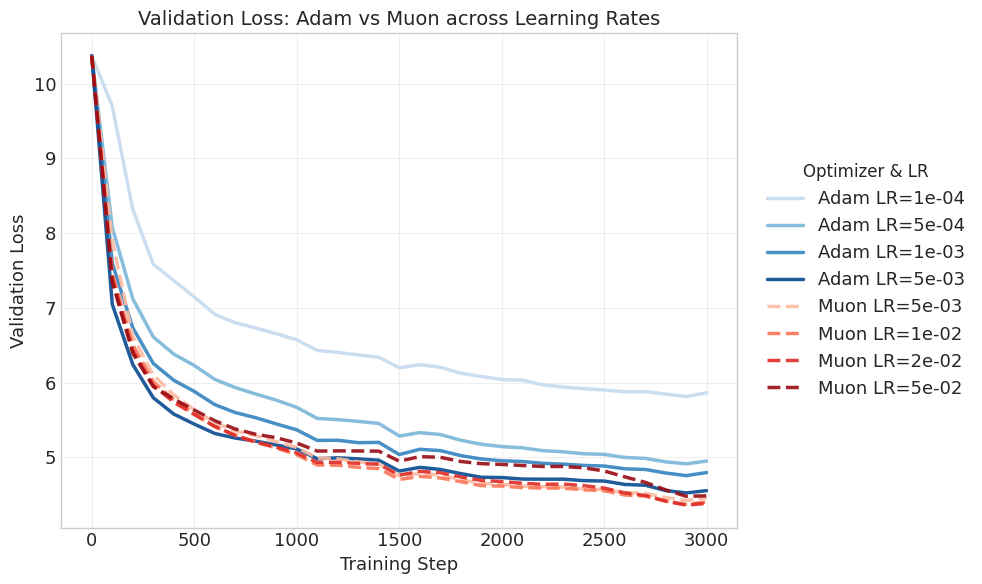

In [33]:
def plot_metric_by_learning_rate(adam_data, muon_data, metric, ylabel, title_suffix=''):
    """Plot metric across learning rates for both optimizers on same plot."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Adam lines (solid, blue shades)
    lr_keys = sorted(adam_data['learning_rates'].keys(), 
                     key=lambda x: float(x.replace('e-', 'e-0').replace('e', 'e')))
    colors_adam = get_lr_colormap(lr_keys, 'Blues')
    
    for lr in lr_keys:
        df = adam_data['learning_rates'][lr]
        if metric in df.columns:
            ax.plot(df['step'], df[metric], 
                    label=f'Adam LR={format_lr_label(lr)}', 
                    color=colors_adam[lr], linewidth=2.5, alpha=0.9,
                    linestyle=ADAM_LINESTYLE)
    
    # Muon lines (dashed, red shades)
    lr_keys = sorted(muon_data['learning_rates'].keys(),
                     key=lambda x: float(x))
    colors_muon = get_lr_colormap(lr_keys, 'Reds')
    
    for lr in lr_keys:
        df = muon_data['learning_rates'][lr]
        if metric in df.columns:
            ax.plot(df['step'], df[metric], 
                    label=f'Muon LR={format_lr_label(lr)}',
                    color=colors_muon[lr], linewidth=2.5, alpha=0.9,
                    linestyle=MUON_LINESTYLE)
    
    ax.set_xlabel('Training Step', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title_suffix)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='Optimizer & LR', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=13)
    ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=13)
    
    plt.tight_layout()
    return fig

# Plot Validation Loss by Learning Rate
fig = plot_metric_by_learning_rate(
    adam_data, muon_data,
    metric='val_loss',
    ylabel='Validation Loss',
    title_suffix='Validation Loss: Adam vs Muon across Learning Rates'
)
plt.savefig('../ablation_results/plots/val_loss_by_lr.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_103616/397432299.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
/tmp/ipykernel_103616/2892028166.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=13)
/tmp/ipykernel_103616/2892028166.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=13)


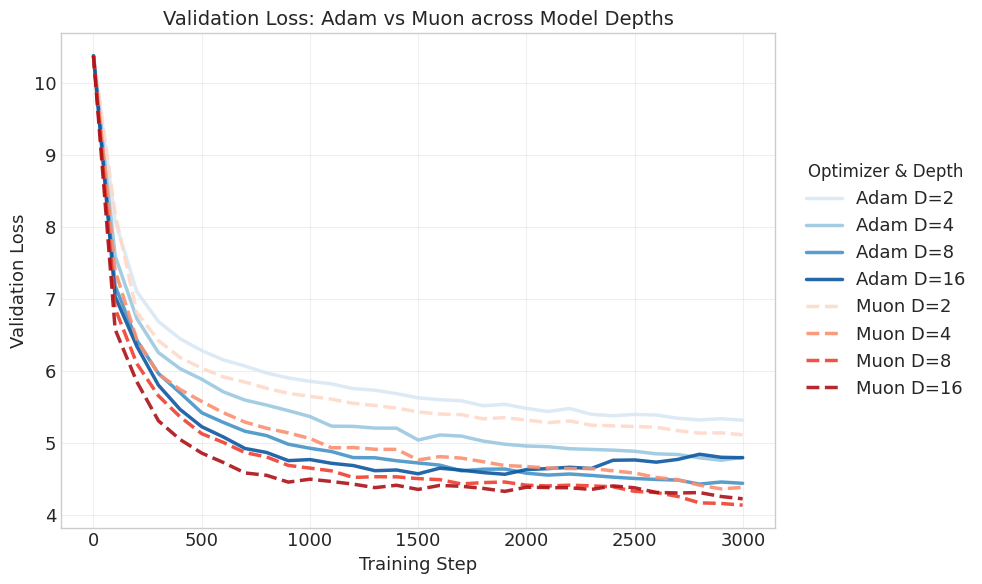

In [34]:
def plot_metric_by_depth(adam_data, muon_data, metric, ylabel, title_suffix=''):
    """Plot metric across depths for both optimizers on same plot."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Adam lines (solid, blue shades)
    depths = sorted(adam_data['depths'].keys())
    colors_adam = get_depth_colormap(depths, 'Blues')
    
    for depth in depths:
        df = adam_data['depths'][depth]
        if metric in df.columns:
            ax.plot(df['step'], df[metric], 
                    label=f'Adam D={depth}',
                    color=colors_adam[depth], linewidth=2.5, alpha=0.9,
                    linestyle=ADAM_LINESTYLE)
    
    # Muon lines (dashed, red shades)
    depths = sorted(muon_data['depths'].keys())
    colors_muon = get_depth_colormap(depths, 'Reds')
    
    for depth in depths:
        df = muon_data['depths'][depth]
        if metric in df.columns:
            ax.plot(df['step'], df[metric], 
                    label=f'Muon D={depth}',
                    color=colors_muon[depth], linewidth=2.5, alpha=0.9,
                    linestyle=MUON_LINESTYLE)
    
    ax.set_xlabel('Training Step', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title_suffix)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='Optimizer & Depth', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=13)
    ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=13)
    
    plt.tight_layout()
    return fig

# Plot Validation Loss by Depth
fig = plot_metric_by_depth(
    adam_data, muon_data,
    metric='val_loss',
    ylabel='Validation Loss',
    title_suffix='Validation Loss: Adam vs Muon across Model Depths'
)
plt.savefig('../ablation_results/plots/val_loss_by_depth.png', bbox_inches='tight')
plt.show()

## 4. Perplexity Comparison

/tmp/ipykernel_103616/397432299.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
/tmp/ipykernel_103616/1348545628.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=13)
/tmp/ipykernel_103616/1348545628.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=13)


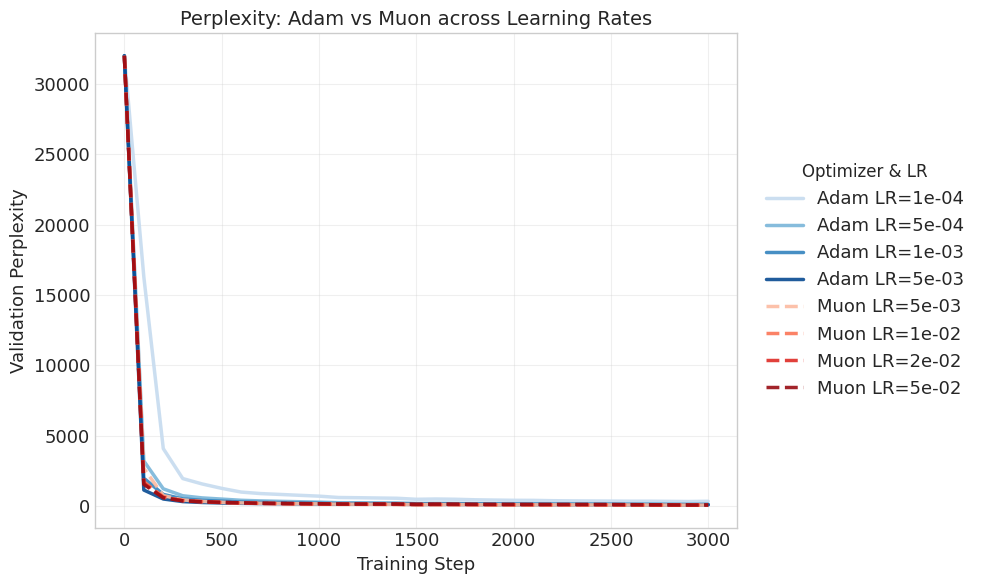

In [35]:
# Plot Perplexity by Learning Rate
fig = plot_metric_by_learning_rate(
    adam_data, muon_data,
    metric='val_perplexity',
    ylabel='Validation Perplexity',
    title_suffix='Perplexity: Adam vs Muon across Learning Rates'
)
plt.savefig('../ablation_results/plots/perplexity_by_lr.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_103616/397432299.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
/tmp/ipykernel_103616/2892028166.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=13)
/tmp/ipykernel_103616/2892028166.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=13)


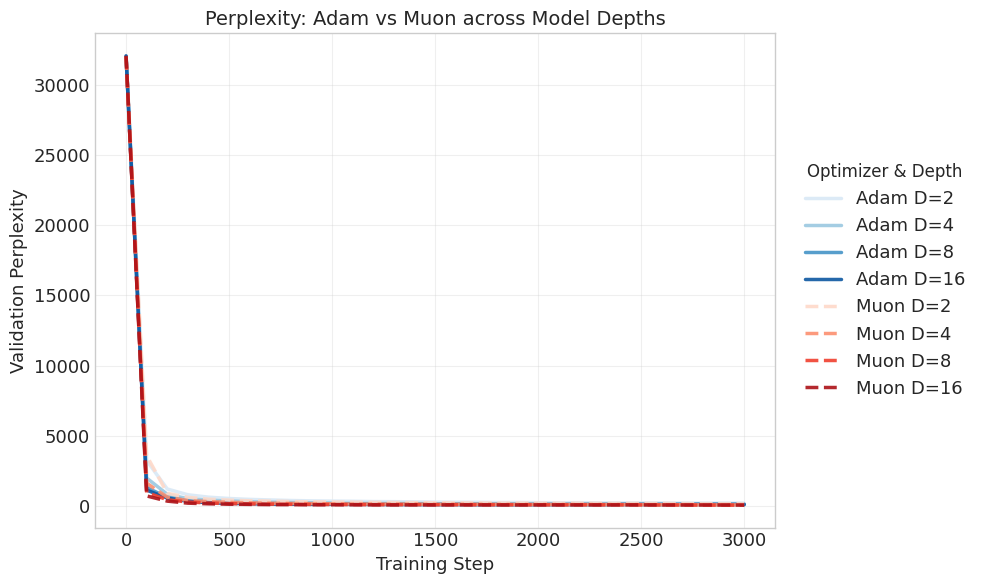

In [36]:
# Plot Perplexity by Depth
fig = plot_metric_by_depth(
    adam_data, muon_data,
    metric='val_perplexity',
    ylabel='Validation Perplexity',
    title_suffix='Perplexity: Adam vs Muon across Model Depths'
)
plt.savefig('../ablation_results/plots/perplexity_by_depth.png', bbox_inches='tight')
plt.show()

## 5. Spectral Entropy of Weight Matrices (W)

/tmp/ipykernel_103616/397432299.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
/tmp/ipykernel_103616/1348545628.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=13)
/tmp/ipykernel_103616/1348545628.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=13)


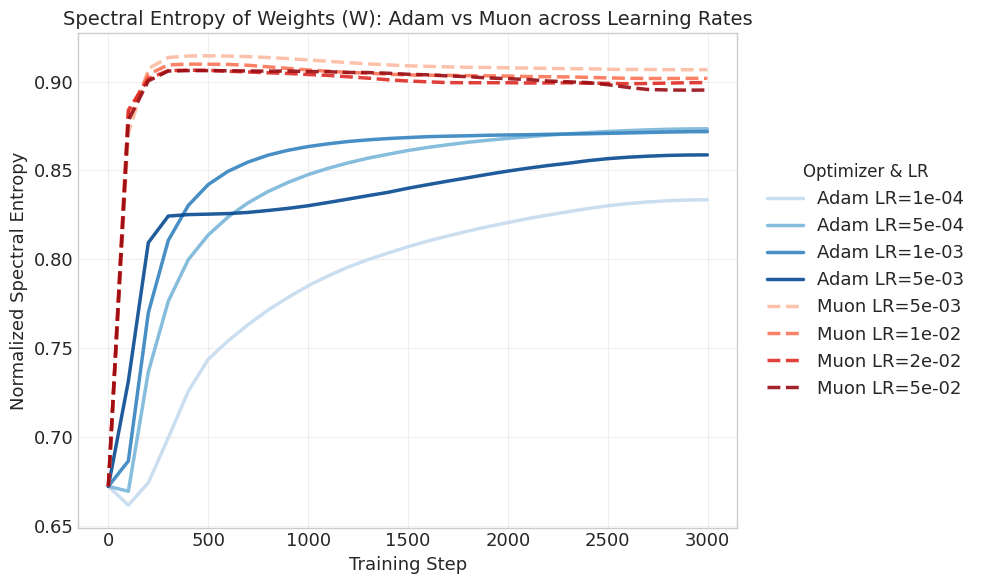

In [37]:
# Plot Spectral Entropy of W by Learning Rate
fig = plot_metric_by_learning_rate(
    adam_data, muon_data,
    metric='spectral_W_mean_normalized_spectral_entropy',
    ylabel='Normalized Spectral Entropy',
    title_suffix='Spectral Entropy of Weights (W): Adam vs Muon across Learning Rates'
)
plt.savefig('../ablation_results/plots/spectral_entropy_W_by_lr.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_103616/397432299.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


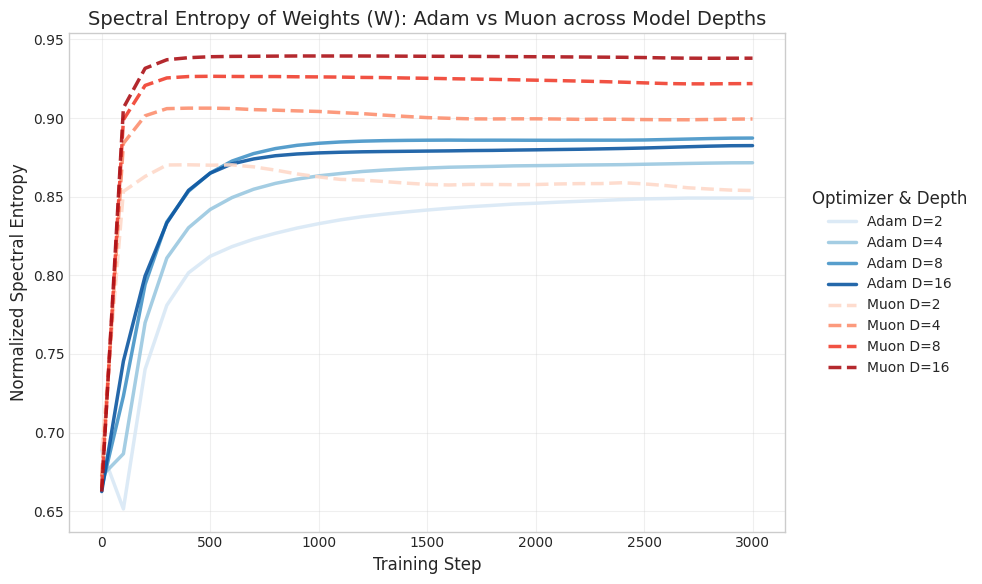

In [26]:
# Plot Spectral Entropy of W by Depth
fig = plot_metric_by_depth(
    adam_data, muon_data,
    metric='spectral_W_mean_normalized_spectral_entropy',
    ylabel='Normalized Spectral Entropy',
    title_suffix='Spectral Entropy of Weights (W): Adam vs Muon across Model Depths'
)
plt.savefig('../ablation_results/plots/spectral_entropy_W_by_depth.png', bbox_inches='tight')
plt.show()

## 6. Spectral Entropy of Weight Updates (ΔW)

/tmp/ipykernel_103616/397432299.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
/tmp/ipykernel_103616/1348545628.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=13)
/tmp/ipykernel_103616/1348545628.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=13)


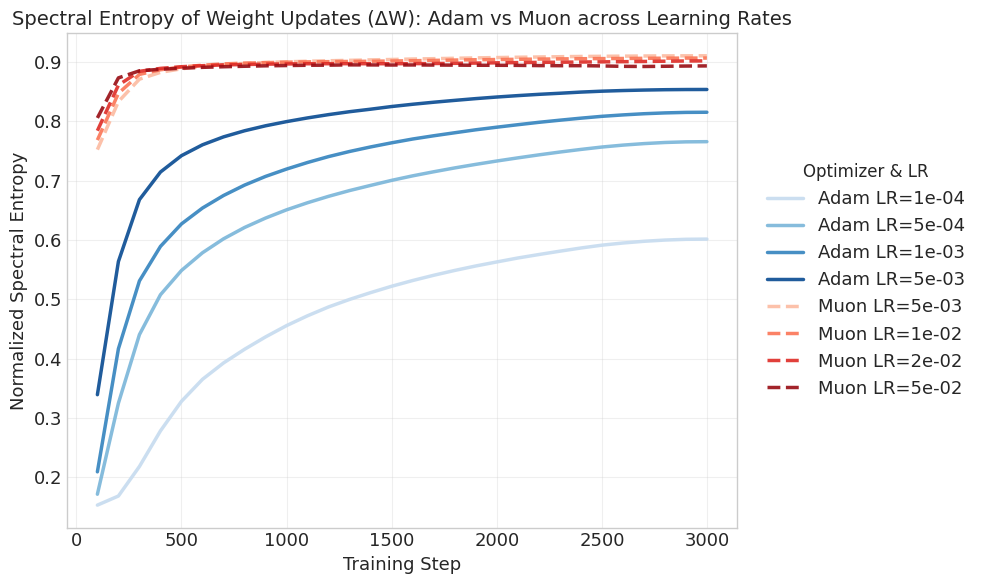

In [38]:
# Plot Spectral Entropy of Delta W by Learning Rate
fig = plot_metric_by_learning_rate(
    adam_data, muon_data,
    metric='spectral_delta_W_mean_normalized_spectral_entropy',
    ylabel='Normalized Spectral Entropy',
    title_suffix='Spectral Entropy of Weight Updates (ΔW): Adam vs Muon across Learning Rates'
)
plt.savefig('../ablation_results/plots/spectral_entropy_deltaW_by_lr.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_103616/397432299.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
/tmp/ipykernel_103616/2892028166.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=13)
/tmp/ipykernel_103616/2892028166.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=13)


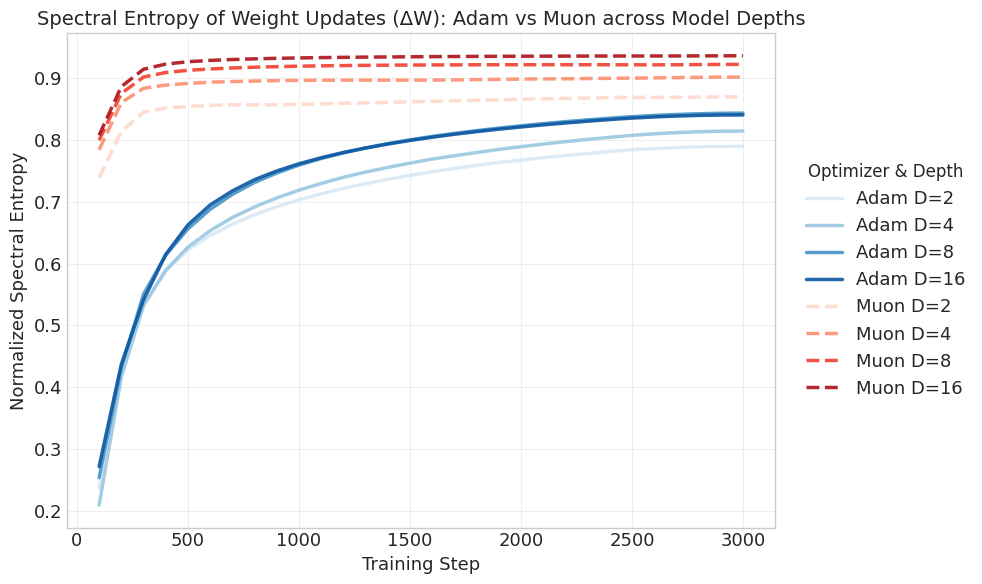

In [39]:
# Plot Spectral Entropy of Delta W by Depth
fig = plot_metric_by_depth(
    adam_data, muon_data,
    metric='spectral_delta_W_mean_normalized_spectral_entropy',
    ylabel='Normalized Spectral Entropy',
    title_suffix='Spectral Entropy of Weight Updates (ΔW): Adam vs Muon across Model Depths'
)
plt.savefig('../ablation_results/plots/spectral_entropy_deltaW_by_depth.png', bbox_inches='tight')
plt.show()

## 7. Per-Depth Direct Comparison Plots

Direct comparison of Adam vs Muon with one subplot per depth configuration.

## 7. Final Metrics Scaling Dashboard

Dashboard-style plots showing how final perplexity, loss, and spectral entropy scale with depth and learning rate.

Saved: ../ablation_results/plots/depth_scaling_dashboard.png


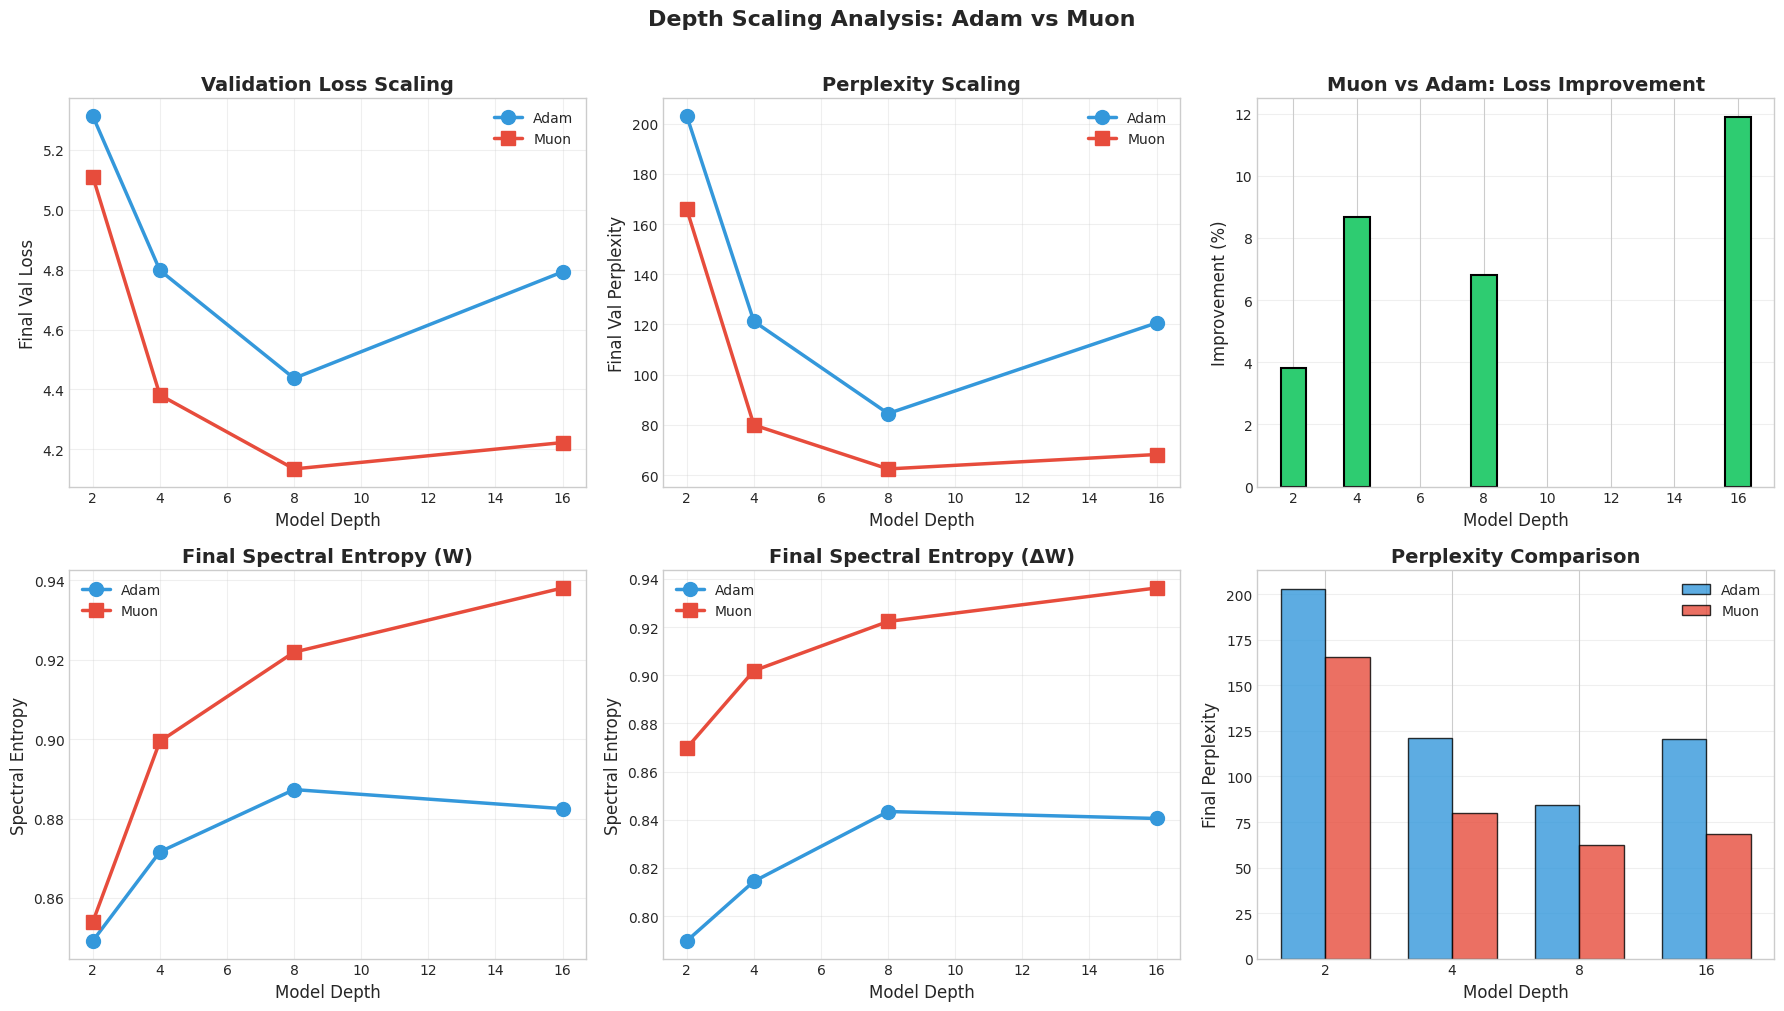

In [44]:
def plot_depth_scaling_dashboard(adam_data, muon_data, save_path=None):
    """
    Create comprehensive dashboard showing how metrics scale with depth.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Get common depths
    adam_depths = sorted(adam_data['depths'].keys())
    muon_depths = sorted(muon_data['depths'].keys())
    sorted_depths = sorted(set(adam_depths) & set(muon_depths))
    
    # Extract final values at each depth
    adam_final = {d: adam_data['depths'][d].iloc[-1].to_dict() for d in sorted_depths if d in adam_data['depths']}
    muon_final = {d: muon_data['depths'][d].iloc[-1].to_dict() for d in sorted_depths if d in muon_data['depths']}
    
    # Plot 1: Final Val Loss vs Depth
    ax = axes[0, 0]
    adam_vals = [adam_final[d].get('val_loss', np.nan) for d in sorted_depths]
    muon_vals = [muon_final[d].get('val_loss', np.nan) for d in sorted_depths]
    ax.plot(sorted_depths, adam_vals, 'o-', color='#3498db', linewidth=2.5, markersize=10, label='Adam')
    ax.plot(sorted_depths, muon_vals, 's-', color='#e74c3c', linewidth=2.5, markersize=10, label='Muon')
    ax.set_xlabel('Model Depth')
    ax.set_ylabel('Final Val Loss')
    ax.set_title('Validation Loss Scaling', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Final Perplexity vs Depth
    ax = axes[0, 1]
    adam_ppl = [adam_final[d].get('val_perplexity', np.nan) for d in sorted_depths]
    muon_ppl = [muon_final[d].get('val_perplexity', np.nan) for d in sorted_depths]
    ax.plot(sorted_depths, adam_ppl, 'o-', color='#3498db', linewidth=2.5, markersize=10, label='Adam')
    ax.plot(sorted_depths, muon_ppl, 's-', color='#e74c3c', linewidth=2.5, markersize=10, label='Muon')
    ax.set_xlabel('Model Depth')
    ax.set_ylabel('Final Val Perplexity')
    ax.set_title('Perplexity Scaling', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Improvement ratio (Muon vs Adam) - Loss
    ax = axes[0, 2]
    improvement = [(a - m) / a * 100 if a and m and a > 0 else np.nan 
                   for a, m in zip(adam_vals, muon_vals)]
    colors = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvement]
    ax.bar(sorted_depths, improvement, color=colors, edgecolor='black', linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Model Depth')
    ax.set_ylabel('Improvement (%)')
    ax.set_title('Muon vs Adam: Loss Improvement', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Final Spectral Entropy (W) vs Depth
    ax = axes[1, 0]
    adam_se = [adam_final[d].get('spectral_W_mean_normalized_spectral_entropy', np.nan) for d in sorted_depths]
    muon_se = [muon_final[d].get('spectral_W_mean_normalized_spectral_entropy', np.nan) for d in sorted_depths]
    ax.plot(sorted_depths, adam_se, 'o-', color='#3498db', linewidth=2.5, markersize=10, label='Adam')
    ax.plot(sorted_depths, muon_se, 's-', color='#e74c3c', linewidth=2.5, markersize=10, label='Muon')
    ax.set_xlabel('Model Depth')
    ax.set_ylabel('Spectral Entropy')
    ax.set_title('Final Spectral Entropy (W)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 5: Final Spectral Entropy (ΔW) vs Depth
    ax = axes[1, 1]
    adam_dw = [adam_final[d].get('spectral_delta_W_mean_normalized_spectral_entropy', np.nan) for d in sorted_depths]
    muon_dw = [muon_final[d].get('spectral_delta_W_mean_normalized_spectral_entropy', np.nan) for d in sorted_depths]
    ax.plot(sorted_depths, adam_dw, 'o-', color='#3498db', linewidth=2.5, markersize=10, label='Adam')
    ax.plot(sorted_depths, muon_dw, 's-', color='#e74c3c', linewidth=2.5, markersize=10, label='Muon')
    ax.set_xlabel('Model Depth')
    ax.set_ylabel('Spectral Entropy')
    ax.set_title('Final Spectral Entropy (ΔW)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 6: Combined bar chart
    ax = axes[1, 2]
    x = np.arange(len(sorted_depths))
    width = 0.35
    ax.bar(x - width/2, adam_ppl, width, label='Adam', color='#3498db', alpha=0.8, edgecolor='black')
    ax.bar(x + width/2, muon_ppl, width, label='Muon', color='#e74c3c', alpha=0.8, edgecolor='black')
    ax.set_xlabel('Model Depth')
    ax.set_ylabel('Final Perplexity')
    ax.set_title('Perplexity Comparison', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_depths)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    fig.suptitle('Depth Scaling Analysis: Adam vs Muon', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()

# Create depth scaling dashboard
plot_depth_scaling_dashboard(adam_data, muon_data, 
                             save_path='../ablation_results/plots/depth_scaling_dashboard.png')

Saved: ../ablation_results/plots/depth_scaling_dashboard.png


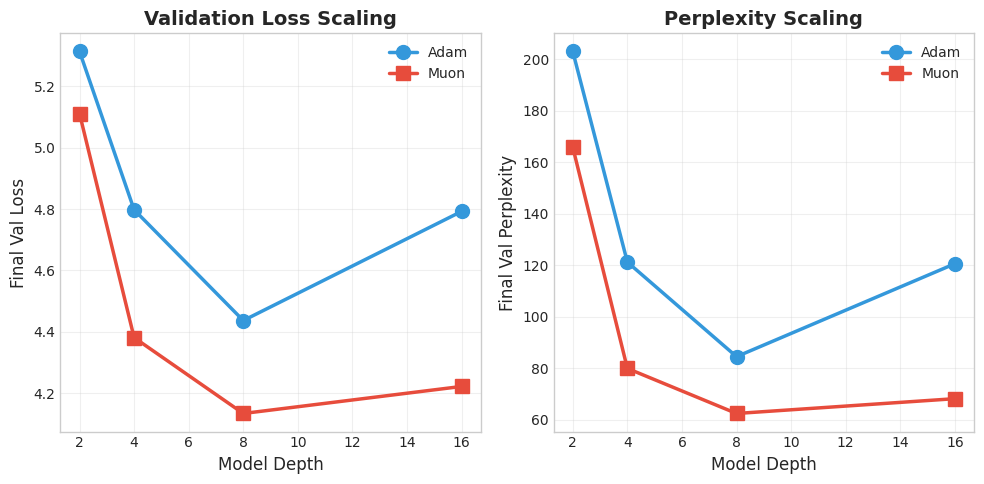

In [47]:
def plot_depth_scaling_dashboard(adam_data, muon_data, save_path=None):
    """
    Create comprehensive dashboard showing how metrics scale with depth.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    
    # Get common depths
    adam_depths = sorted(adam_data['depths'].keys())
    muon_depths = sorted(muon_data['depths'].keys())
    sorted_depths = sorted(set(adam_depths) & set(muon_depths))
    
    # Extract final values at each depth
    adam_final = {d: adam_data['depths'][d].iloc[-1].to_dict() for d in sorted_depths if d in adam_data['depths']}
    muon_final = {d: muon_data['depths'][d].iloc[-1].to_dict() for d in sorted_depths if d in muon_data['depths']}
    
    # Plot 1: Final Val Loss vs Depth
    ax = axes[0]
    adam_vals = [adam_final[d].get('val_loss', np.nan) for d in sorted_depths]
    muon_vals = [muon_final[d].get('val_loss', np.nan) for d in sorted_depths]
    ax.plot(sorted_depths, adam_vals, 'o-', color='#3498db', linewidth=2.5, markersize=10, label='Adam')
    ax.plot(sorted_depths, muon_vals, 's-', color='#e74c3c', linewidth=2.5, markersize=10, label='Muon')
    ax.set_xlabel('Model Depth')
    ax.set_ylabel('Final Val Loss')
    ax.set_title('Validation Loss Scaling', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Final Perplexity vs Depth
    ax = axes[1]
    adam_ppl = [adam_final[d].get('val_perplexity', np.nan) for d in sorted_depths]
    muon_ppl = [muon_final[d].get('val_perplexity', np.nan) for d in sorted_depths]
    ax.plot(sorted_depths, adam_ppl, 'o-', color='#3498db', linewidth=2.5, markersize=10, label='Adam')
    ax.plot(sorted_depths, muon_ppl, 's-', color='#e74c3c', linewidth=2.5, markersize=10, label='Muon')
    ax.set_xlabel('Model Depth')
    ax.set_ylabel('Final Val Perplexity')
    ax.set_title('Perplexity Scaling', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()

# Create depth scaling dashboard
plot_depth_scaling_dashboard(adam_data, muon_data, 
                             save_path='../ablation_results/plots/depth_scaling_dashboard.png')

## 8. Per-Depth Direct Comparison Plots

Direct comparison of Adam vs Muon with one subplot per depth configuration.

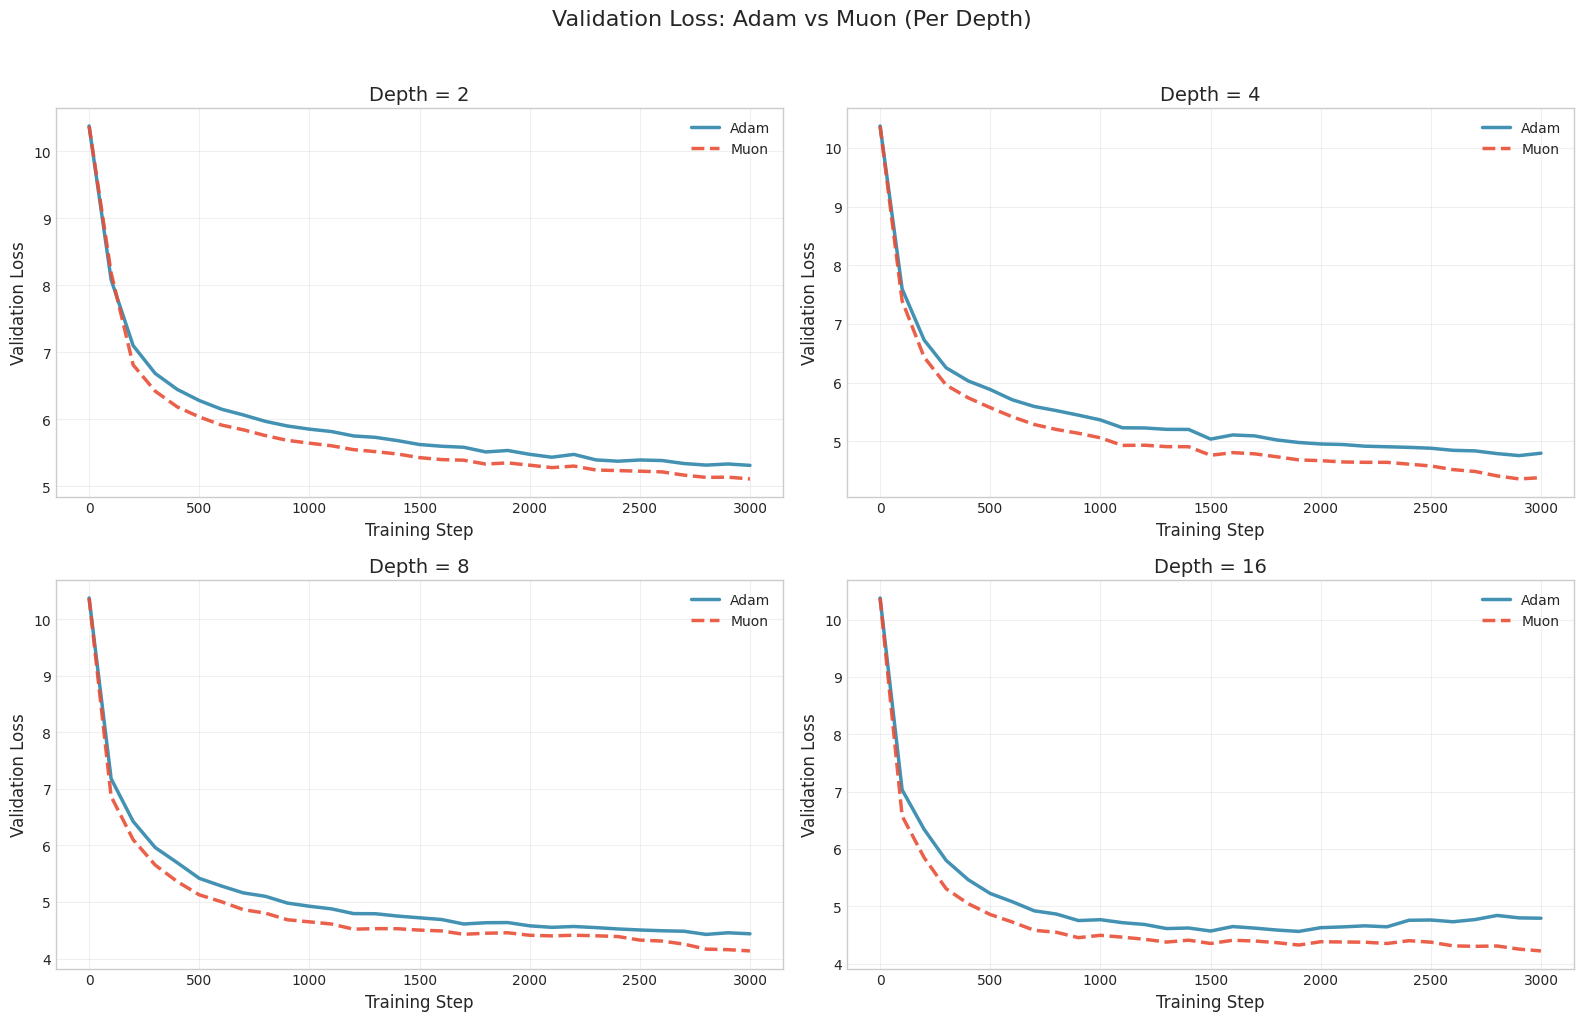

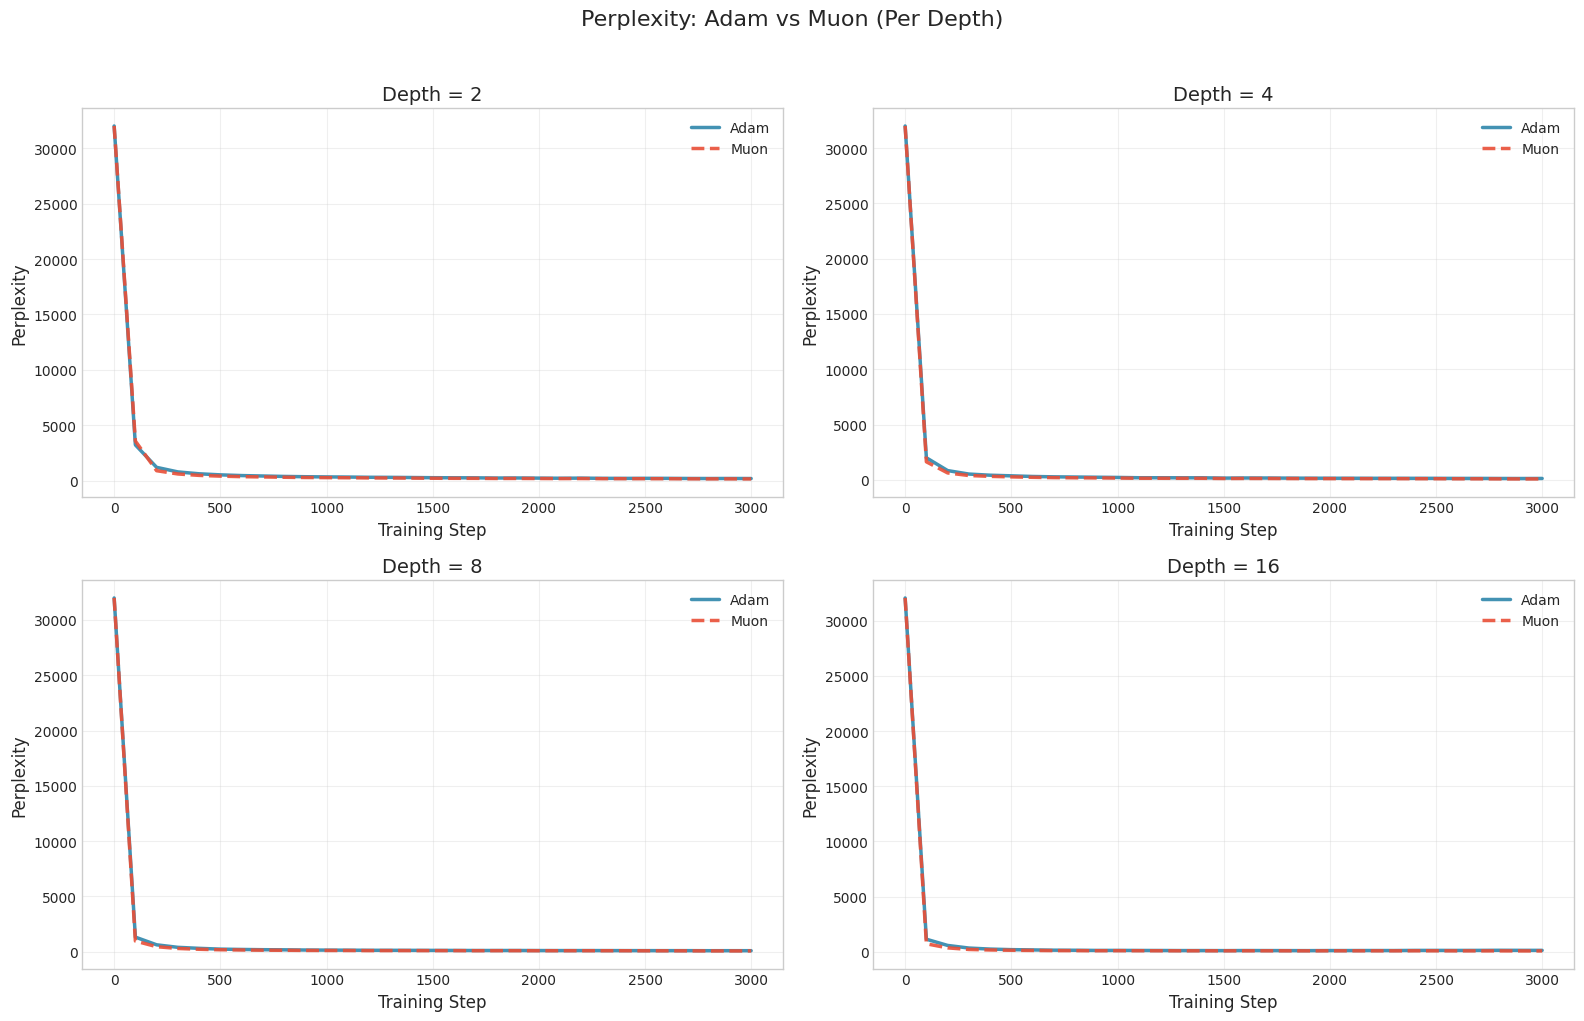

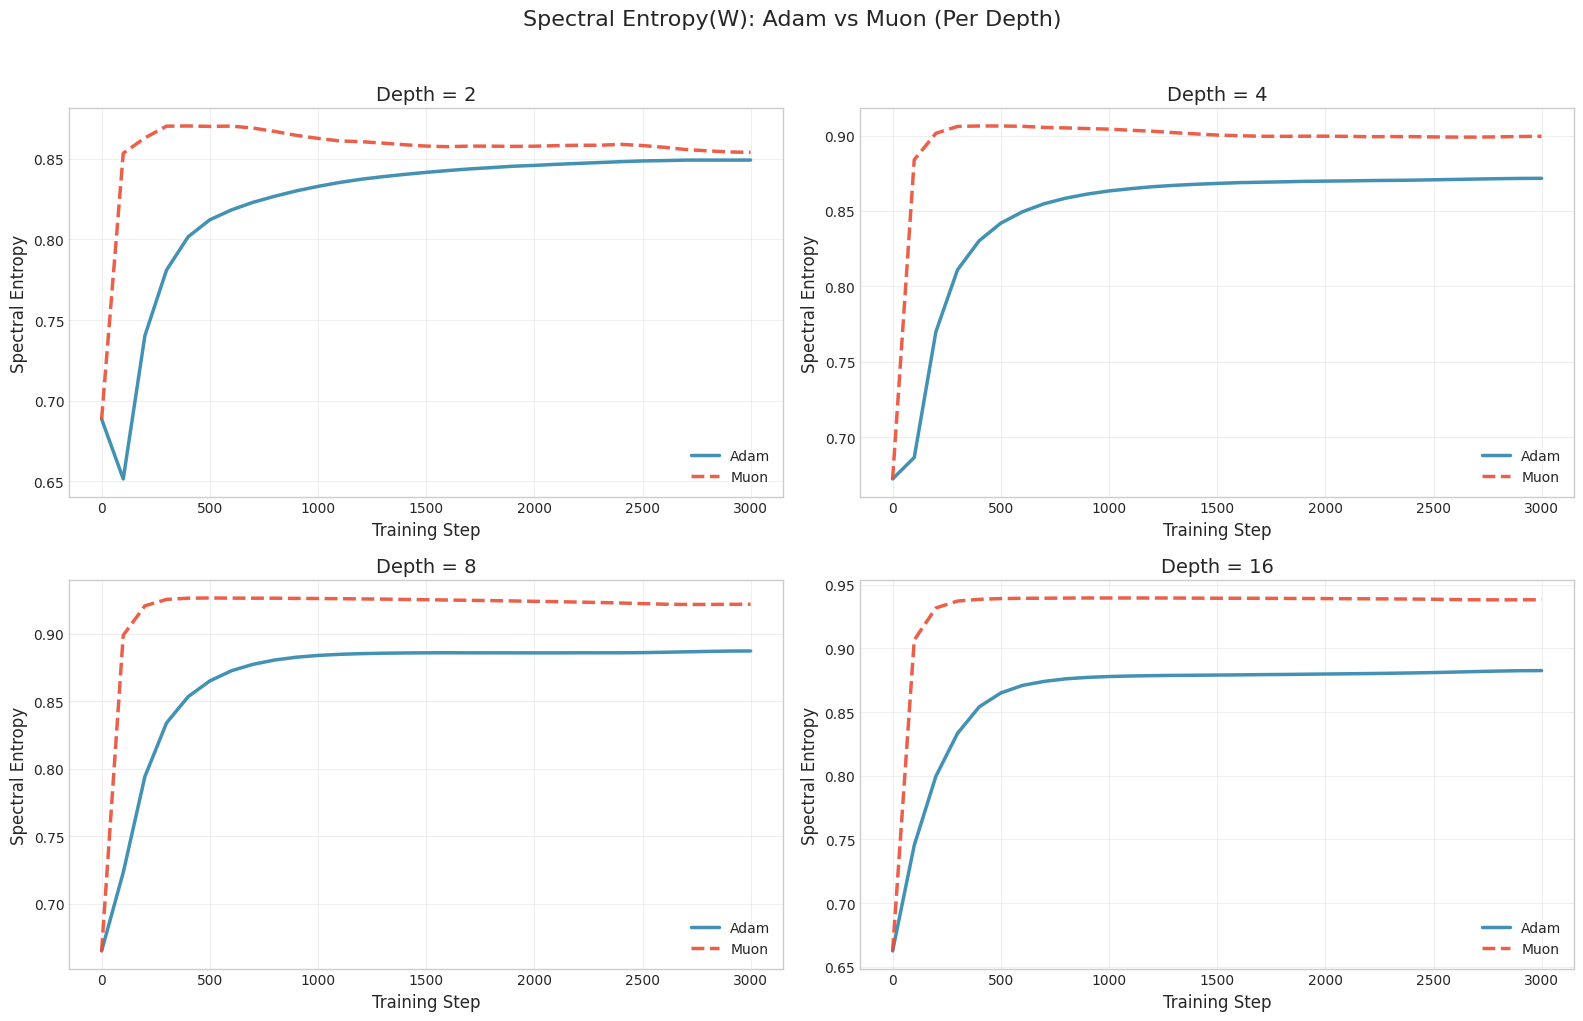

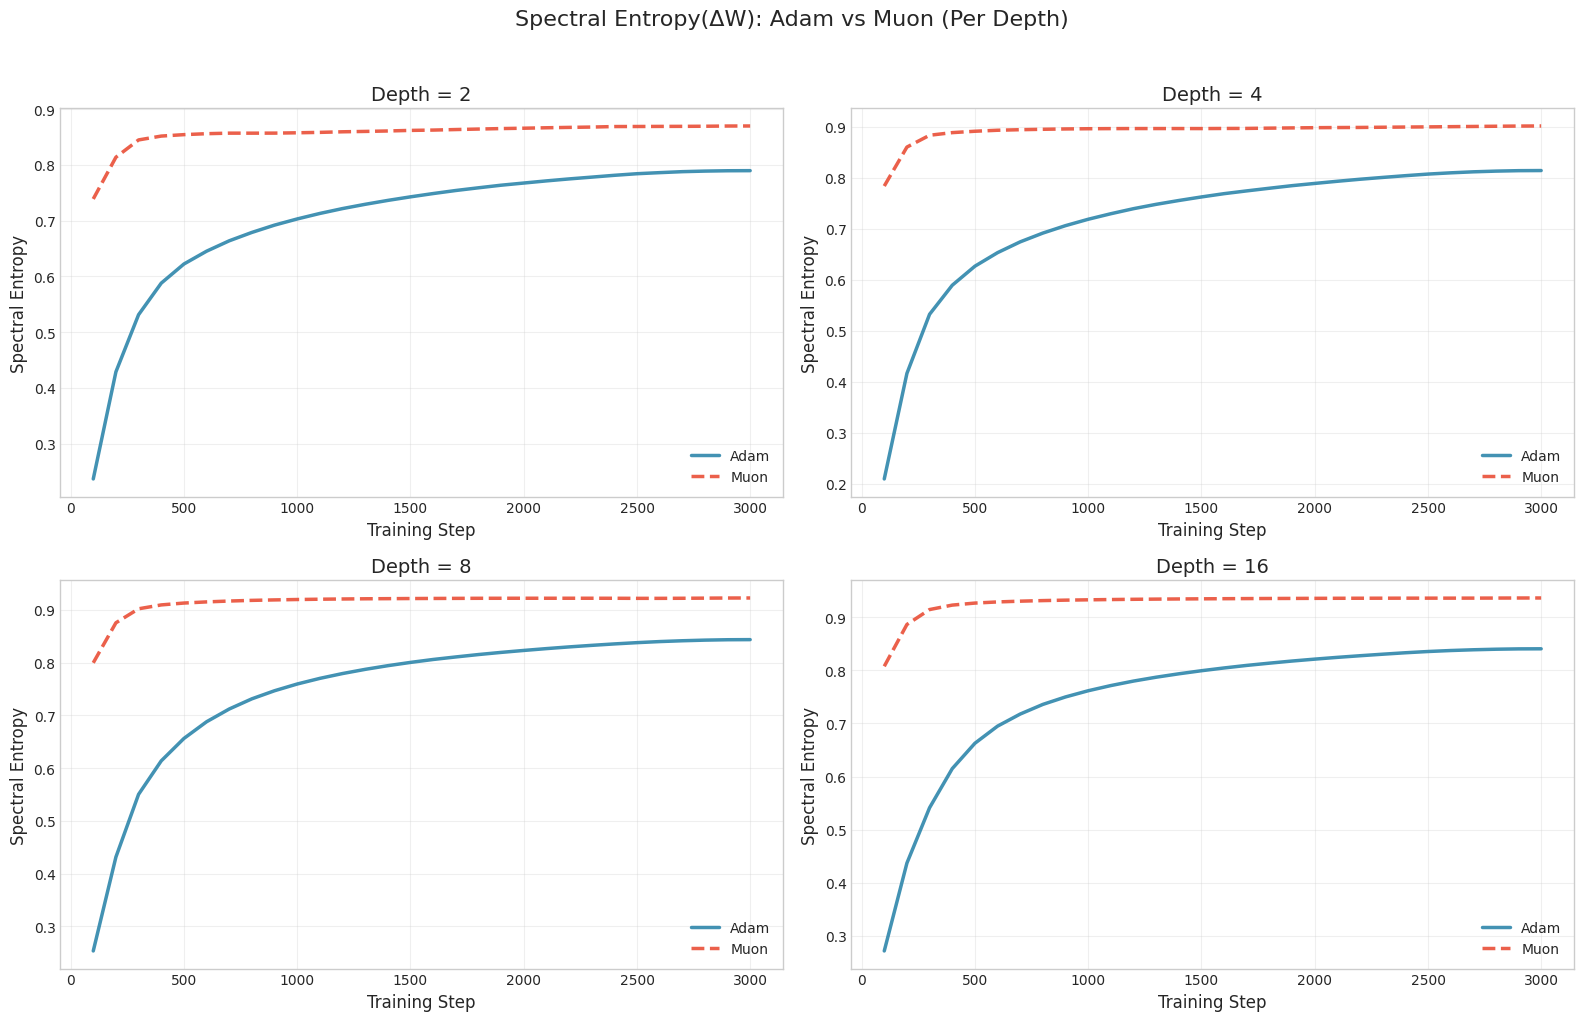

In [40]:
def plot_direct_comparison_depth(adam_data, muon_data, metric, ylabel, title):
    """Plot direct comparison on same axes for each depth (subplots)."""
    adam_depths = sorted(adam_data['depths'].keys())
    muon_depths = sorted(muon_data['depths'].keys())
    common_depths = sorted(set(adam_depths) & set(muon_depths))
    
    n_depths = len(common_depths)
    ncols = min(2, n_depths)
    nrows = (n_depths + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
    if n_depths == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, depth in enumerate(common_depths):
        ax = axes[idx]
        
        # Adam (solid line)
        df_adam = adam_data['depths'][depth]
        if metric in df_adam.columns:
            ax.plot(df_adam['step'], df_adam[metric], 
                    label='Adam', color=ADAM_COLOR, linewidth=2.5, alpha=0.9,
                    linestyle='-')
        
        # Muon (dashed line)
        df_muon = muon_data['depths'][depth]
        if metric in df_muon.columns:
            ax.plot(df_muon['step'], df_muon[metric],
                    label='Muon', color=MUON_COLOR, linewidth=2.5, alpha=0.9,
                    linestyle='--')
        
        ax.set_xlabel('Training Step')
        ax.set_ylabel(ylabel)
        ax.set_title(f'Depth = {depth}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(common_depths), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    return fig

# Direct comparison for all metrics by depth (subplot per depth)
metrics_info = [
    ('val_loss', 'Validation Loss', 'Validation Loss: Adam vs Muon (Per Depth)'),
    ('val_perplexity', 'Perplexity', 'Perplexity: Adam vs Muon (Per Depth)'),
    ('spectral_W_mean_normalized_spectral_entropy', 'Spectral Entropy', 'Spectral Entropy(W): Adam vs Muon (Per Depth)'),
    ('spectral_delta_W_mean_normalized_spectral_entropy', 'Spectral Entropy', 'Spectral Entropy(ΔW): Adam vs Muon (Per Depth)'),
]

for metric, ylabel, title in metrics_info:
    fig = plot_direct_comparison_depth(adam_data, muon_data, metric, ylabel, title)
    metric_short = metric.replace('spectral_', '').replace('_mean_normalized_spectral_entropy', '')
    filename = f"direct_comparison_{metric_short}_depth.png"
    plt.savefig(f'../ablation_results/plots/{filename}', bbox_inches='tight')
    plt.show()

## 9. Final Performance Summary (Bar Charts)

Grouped bar charts showing final metrics achieved by each optimizer configuration.

In [41]:
def extract_final_metrics(data, category='learning_rates'):
    """Extract final (last step) metrics from each experiment."""
    results = []
    for key, df in data[category].items():
        final_row = df.iloc[-1].to_dict()
        final_row['config'] = key
        results.append(final_row)
    return pd.DataFrame(results)

# Extract final metrics
adam_final_lr = extract_final_metrics(adam_data, 'learning_rates')
adam_final_lr['optimizer'] = 'Adam'
muon_final_lr = extract_final_metrics(muon_data, 'learning_rates')
muon_final_lr['optimizer'] = 'Muon'

adam_final_depth = extract_final_metrics(adam_data, 'depths')
adam_final_depth['optimizer'] = 'Adam'
muon_final_depth = extract_final_metrics(muon_data, 'depths')
muon_final_depth['optimizer'] = 'Muon'

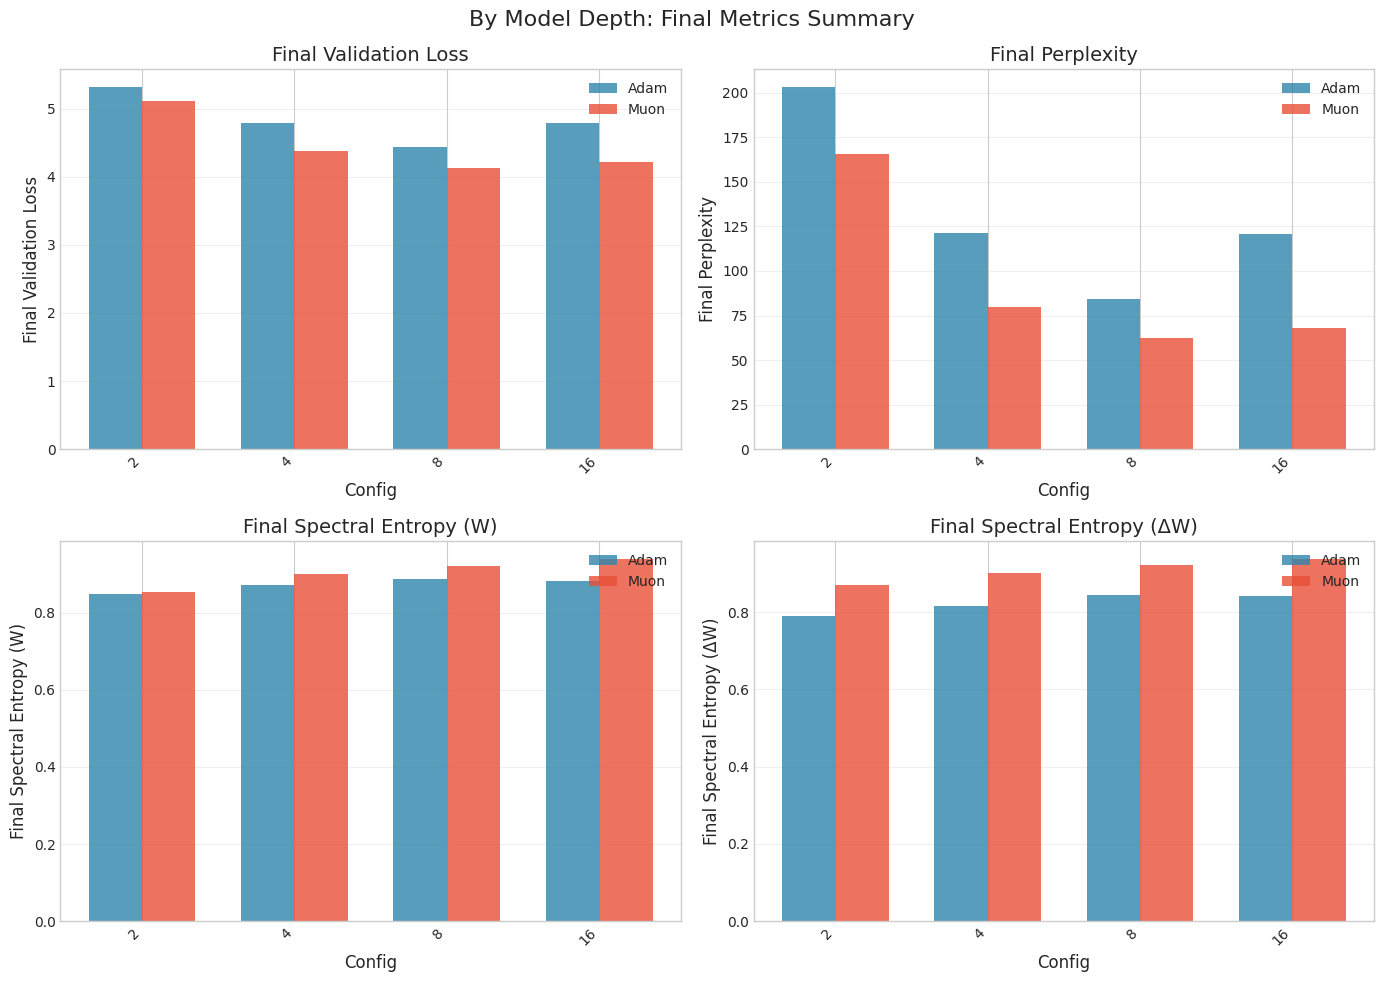

In [42]:
def plot_final_metrics_summary(adam_final, muon_final, config_col, metrics_to_plot, title_prefix):
    """Create summary bar plots for final metrics."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (metric, ylabel) in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Prepare data
        adam_vals = adam_final[[config_col, metric]].copy()
        adam_vals['optimizer'] = 'Adam'
        muon_vals = muon_final[[config_col, metric]].copy()
        muon_vals['optimizer'] = 'Muon'
        
        combined = pd.concat([adam_vals, muon_vals], ignore_index=True)
        combined = combined.dropna(subset=[metric])
        
        # Sort by config
        try:
            combined['sort_key'] = combined[config_col].astype(float)
        except:
            combined['sort_key'] = combined[config_col]
        combined = combined.sort_values('sort_key')
        
        # Create grouped bar plot
        configs = combined[config_col].unique()
        x = np.arange(len(configs))
        width = 0.35
        
        adam_heights = []
        muon_heights = []
        for config in configs:
            adam_val = combined[(combined[config_col] == config) & (combined['optimizer'] == 'Adam')][metric]
            muon_val = combined[(combined[config_col] == config) & (combined['optimizer'] == 'Muon')][metric]
            adam_heights.append(adam_val.values[0] if len(adam_val) > 0 else 0)
            muon_heights.append(muon_val.values[0] if len(muon_val) > 0 else 0)
        
        bars1 = ax.bar(x - width/2, adam_heights, width, label='Adam', color=ADAM_COLOR, alpha=0.8)
        bars2 = ax.bar(x + width/2, muon_heights, width, label='Muon', color=MUON_COLOR, alpha=0.8)
        
        ax.set_xlabel(config_col.replace('_', ' ').title())
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels([str(c) for c in configs], rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'{title_prefix}: Final Metrics Summary', fontsize=16)
    plt.tight_layout()
    return fig

# Plot final metrics by depth
metrics_to_plot = [
    ('val_loss', 'Final Validation Loss'),
    ('val_perplexity', 'Final Perplexity'),
    ('spectral_W_mean_normalized_spectral_entropy', 'Final Spectral Entropy (W)'),
    ('spectral_delta_W_mean_normalized_spectral_entropy', 'Final Spectral Entropy (ΔW)'),
]

fig = plot_final_metrics_summary(adam_final_depth, muon_final_depth, 'config', metrics_to_plot, 'By Model Depth')
plt.savefig('../ablation_results/plots/final_summary_by_depth.png', bbox_inches='tight')
plt.show()

In [43]:
# Display summary table
print("\n" + "="*80)
print("FINAL METRICS SUMMARY - By Model Depth")
print("="*80)

combined_depth = pd.concat([adam_final_depth, muon_final_depth], ignore_index=True)
summary_cols = ['optimizer', 'config', 'val_loss', 'val_perplexity', 
                'spectral_W_mean_normalized_spectral_entropy',
                'spectral_delta_W_mean_normalized_spectral_entropy']
summary_cols = [c for c in summary_cols if c in combined_depth.columns]

display_df = combined_depth[summary_cols].copy()
display_df.columns = ['Optimizer', 'Depth', 'Val Loss', 'Perplexity', 'Entropy(W)', 'Entropy(ΔW)']
display_df = display_df.sort_values(['Depth', 'Optimizer'])
print(display_df.to_string(index=False))


FINAL METRICS SUMMARY - By Model Depth
Optimizer  Depth  Val Loss  Perplexity  Entropy(W)  Entropy(ΔW)
     Adam      2  5.313469  203.053484    0.849176     0.789671
     Muon      2  5.111116  165.855264    0.853963     0.869780
     Adam      4  4.797741  121.236187    0.871625     0.814401
     Muon      4  4.381265   79.939117    0.899460     0.901868
     Adam      8  4.436887   84.511470    0.887314     0.843404
     Muon      8  4.134139   62.435834    0.921948     0.922299
     Adam     16  4.792491  120.601466    0.882513     0.840510
     Muon     16  4.222223   68.184871    0.938113     0.936208


## 10. Save Plots Directory

In [ ]:
# Ensure plots directory exists
plots_dir = Path('../ablation_results/plots')
plots_dir.mkdir(exist_ok=True)

print(f"All plots saved to: {plots_dir.resolve()}")
print("\nGenerated plots:")
for f in sorted(plots_dir.glob('*.png')):
    print(f"  - {f.name}")

## 11. Key Observations

### Validation Loss & Perplexity
- Compare convergence speed between Adam and Muon
- Identify optimal learning rates for each optimizer
- Analyze scaling behavior with model depth

### Spectral Entropy Insights
- **High spectral entropy (W)**: Weight matrices utilize more singular values effectively
- **Low spectral entropy (W)**: Weight matrices are more low-rank (concentrated singular values)
- **Spectral entropy (ΔW)**: Reveals update dynamics and optimization behavior

### Muon vs Adam
- Muon typically shows higher spectral entropy in weight matrices
- Different learning rate sensitivities between optimizers
- Depth scaling effects may differ